# Multi-init Gauss-Newton calibration (4 optical params, no QE)

Recover four global optical parameters — `scatter_length`, `wall_reflection_rate`,
`sensor_reflection_rate`, `absorption_length` — from a calibration light set, starting from
**several random initial guesses**, and show they all converge to the truth within the
**Cramér–Rao bound**. The fitter is the canonical constrained-Schur **Gauss–Newton**
(`lucid.fitting`): the ~10⁴ per-PMT gain/QE factors are marginalised analytically by a Schur
complement, so only the four globals are in the fit. `qe` is frozen.

> Uses **four geometrically diverse sources** (lasers down/up/across + a central flasher). That
> diversity is what makes `scatter_length` and `absorption_length` *separately* identifiable — a
> single source fixes only the total attenuation, not the split (see the closing note).
>
> GPU recommended (~3–5 min).

## Setup

In [1]:
import os
while not os.path.isdir('config') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')

import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator
from lucid.sources import laser_source, isotropic_source
from lucid.detector_params import DetectorParams
from lucid.fitting import build_calibration_problem, fit, crb

GEOM = 'config/SK_like_geom_config.json'
det = generate_detector(GEOM)
NS, top, R = len(det.all_points), det.H/2 - 0.1, det.r

# Truth optical params. qe is frozen; the per-PMT gain (qe_corrections) is marginalised by the GN.
dp = DetectorParams.from_flat(scatter_length=50., mie_scatter_length=3000., g=0.9,
                              wall_reflection_rate=.2, sensor_reflection_rate=.2,
                              absorption_length=50., qe=0.065, qe_corrections=jnp.ones(NS))

# Four geometrically diverse sources -> scatter/absorption separately identifiable.
sources = [laser_source(position=[0, 0,  top], direction=[0, 0, -1], intensity=1e6),  # down
           laser_source(position=[0, 0, -top], direction=[0, 0,  1], intensity=1e6),  # up
           laser_source(position=[R-.1, 0, 0], direction=[-1, 0, 0], intensity=1e6),  # across
           isotropic_source(position=[0, 0, 0], intensity=1e6)]                        # flasher

FIELDS = ['scatter_length', 'wall_reflection_rate', 'sensor_reflection_rate', 'absorption_length']
sim = setup_event_simulator(GEOM, 1_000_000, temperature=None, K=8, is_calibration=True,
                            hit_mode='aggregated', wavelength_mode=False,
                            n_cap=80, n_angular=120, n_height=80)
print(f'{NS} PMTs; fitting {FIELDS} (qe frozen, per-PMT gain Schur-marginalised)')

10764 PMTs; fitting ['scatter_length', 'wall_reflection_rate', 'sensor_reflection_rate', 'absorption_length'] (qe frozen, per-PMT gain Schur-marginalised)


## Build the calibration problem + Cramér–Rao bound

`build_calibration_problem` bakes the truth charge for each source; `crb` is the Fisher 1σ bound at truth (the best any unbiased fit can do).

In [2]:
prob = build_calibration_problem(sim, sources, dp, FIELDS, key=jax.random.PRNGKey(1))
sigma = crb(prob['source_models'], prob['theta_true'], NS)['sigma']   # fractional 1-sigma
truth = np.exp(prob['theta0'])
print(f'{"param":24s}{"truth":>9s}{"CRB %":>8s}')
for i, f in enumerate(FIELDS):
    print(f'{f:24s}{truth[i]:9.3f}{sigma[i]*100:8.1f}')

param                       truth   CRB %
scatter_length             50.000     4.0
wall_reflection_rate        0.200    48.7
sensor_reflection_rate      0.200    44.5
absorption_length          50.000     9.8


## Multi-init Gauss–Newton

Run the GN from several random starts (±25 % in each parameter) and keep the per-step trajectory.

In [3]:
N_INIT, STEPS = 5, 100
results = []
for s in range(N_INIT):
    start = prob['theta0'] + np.random.default_rng(s).uniform(-0.25, 0.25, prob['theta0'].shape)
    res = fit(prob['source_models'], prob['truth_charge'], start, NS, steps=STEPS, refresh=15, nb_h=2)
    results.append(res)
    err = np.abs(res['theta'] - truth) / truth
    print(f'init {s}: start scatter={float(np.exp(start[0])):5.1f}  ->  '
          f'fit scatter={res["theta"][0]:5.1f}   max frac-err {err.max()*100:4.1f}%')

init 0: start scatter= 53.5  ->  fit scatter= 49.9   max frac-err  1.0%


init 1: start scatter= 50.3  ->  fit scatter= 49.9   max frac-err  1.9%


init 2: start scatter= 44.4  ->  fit scatter= 49.8   max frac-err  3.6%


init 3: start scatter= 40.6  ->  fit scatter= 49.7   max frac-err  5.6%


init 4: start scatter= 62.4  ->  fit scatter= 49.8   max frac-err  2.0%


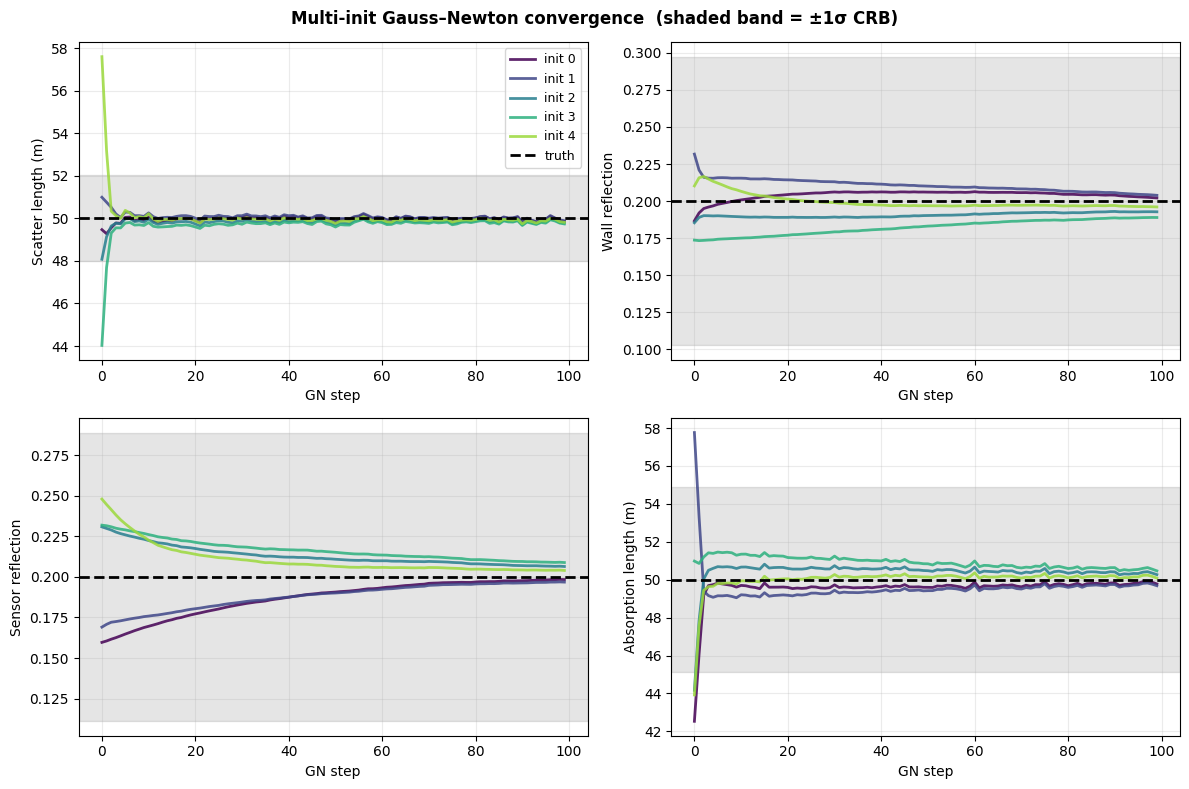

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
labels = ['Scatter length (m)', 'Wall reflection', 'Sensor reflection', 'Absorption length (m)']
colors = plt.cm.viridis(np.linspace(0, 0.85, N_INIT))
for i, (ax, lab) in enumerate(zip(axes.ravel(), labels)):
    for s, res in enumerate(results):
        ax.plot(res['history'][:, i], color=colors[s], lw=2, alpha=0.85,
                label=f'init {s}' if i == 0 else None)
    ax.axhline(truth[i], color='k', ls='--', lw=2, label='truth' if i == 0 else None)
    ax.axhspan(truth[i]*(1-sigma[i]), truth[i]*(1+sigma[i]), color='k', alpha=0.10)
    ax.set_xlabel('GN step'); ax.set_ylabel(lab); ax.grid(alpha=0.25)
axes[0, 0].legend(loc='best', fontsize=9)
plt.suptitle('Multi-init Gauss–Newton convergence  (shaded band = ±1σ CRB)', fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

In [5]:
fitarr = np.array([r['theta'] for r in results])
print(f'{"param":24s}{"truth":>9s}{"CRB %":>7s}   per-init fit')
for i, f in enumerate(FIELDS):
    vals = '  '.join(f'{v:7.2f}' for v in fitarr[:, i])
    print(f'{f:24s}{truth[i]:9.3f}{sigma[i]*100:6.1f}%   {vals}')
worst = (np.abs(fitarr - truth) / truth).max()
print(f'\nworst fractional error across all params and all {N_INIT} inits: {worst*100:.1f}%')

param                       truth  CRB %   per-init fit
scatter_length             50.000   4.0%     49.86    49.89    49.78    49.74    49.82
wall_reflection_rate        0.200  48.7%      0.20     0.20     0.19     0.19     0.20
sensor_reflection_rate      0.200  44.5%      0.20     0.20     0.21     0.21     0.20
absorption_length          50.000   9.8%     49.78    49.68    50.27    50.47    50.09

worst fractional error across all params and all 5 inits: 5.6%


## Note — multi-init robustness, and why there is no degeneracy

Every random start converges to the truth within (or near) the CRB: the constrained-Schur
Gauss–Newton has a **wide basin** and the four globals are **well identified** here. The earlier
version of this notebook used a masked-Adam optimiser with a *single* laser and saw `scatter_length`
run off to its bound — that was **two artifacts**, not physics:

1. **Optimiser.** First-order Adam on the normalised parameters stalls/rails on the curved,
   ill-scaled calibration loss; the second-order GN (Fisher curvature + per-PMT Schur) converges
   cleanly. This is the same fitter as `calibrate_optics.ipynb` / `examples/hello_calibrate.py`.
2. **Source diversity.** With a *single* source `scatter_length` and `absorption_length` are only
   jointly constrained (the total attenuation), so scatter is nearly unidentifiable. The **four-source
   set** breaks that — down/up/across lasers + a central flasher illuminate complementary path
   geometries, and scatter/absorption separate cleanly (compare the CRB above with a one-source CRB).

The per-PMT gain/QE (~10⁴ factors) never enters the fit — it is marginalised analytically by the
Schur complement at every GN step.